In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import shap

In [3]:
df = pd.read_csv(
    "../data/processed/processed_telco.csv"
)

df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,CLTV,Churn Value
0,1,0,0,0,2,1,0,0,2,2,...,0,0,0,0,1,3,53.85,157,3239,1
1,0,0,0,1,2,1,0,1,0,0,...,0,0,0,0,1,2,70.70,925,2701,1
2,0,0,0,1,8,1,2,1,0,0,...,0,2,2,0,1,2,99.65,6104,5372,1
3,0,0,1,1,28,1,2,1,0,0,...,2,2,2,0,1,2,104.80,2646,5003,1
4,1,0,0,1,49,1,2,1,0,2,...,0,2,2,0,1,0,103.70,4265,5340,1


In [4]:
model = joblib.load(
    "../models/churn_model.joblib"
)

In [5]:
target = "Churn Value"

X = df.drop(target, axis=1)

y = df[target]

In [6]:
locals().keys()

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', '_i2', 'pd', 'np', 'plt', 'sns', 'joblib', 'shap', '_i3', 'df', '_3', '_i4', 'model', '_i5', 'target', 'X', 'y', '_i6'])

In [7]:
print(type(model))

<class 'xgboost.sklearn.XGBClassifier'>


In [8]:
importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(20)

,Feature,Importance
14,Contract,0.391570
8,Online Security,0.097343
3,Dependents,0.083421
11,Tech Support,0.062290
7,Internet Service,0.058689
4,Tenure Months,0.032972
13,Streaming Movies,0.030227
5,Phone Service,0.028863
6,Multiple Lines,0.027310
15,Paperless Billing,0.027073


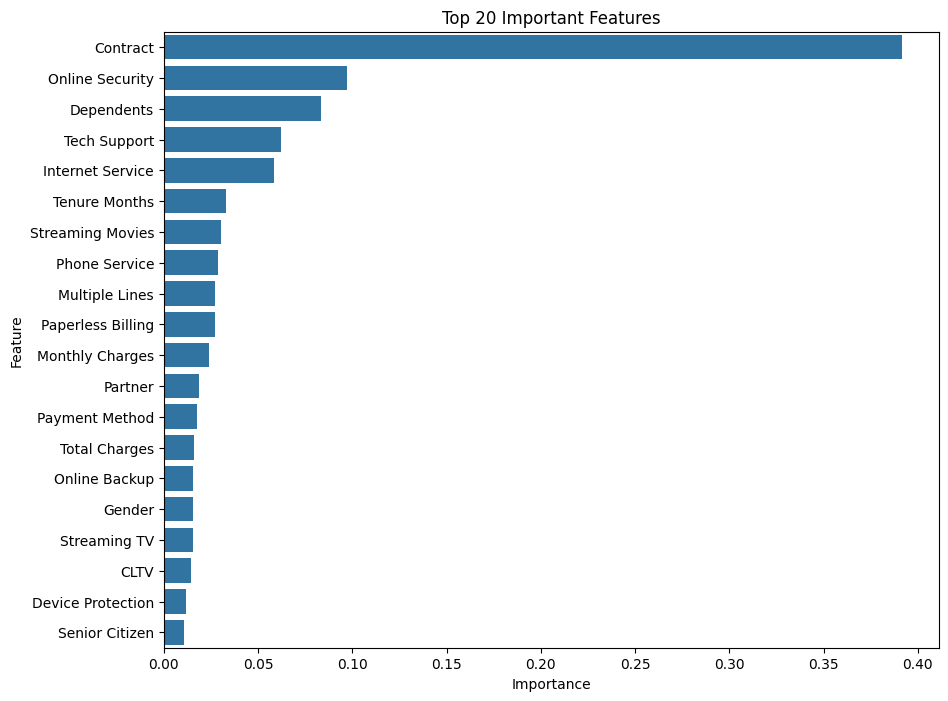

In [9]:
plt.figure(figsize=(10,8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(20)
)

plt.title("Top 20 Important Features")
plt.show()

In [10]:
import os

os.makedirs(
    "../reports",
    exist_ok=True
)

In [11]:
importance_df.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

In [12]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [13]:
import shap

In [14]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X)

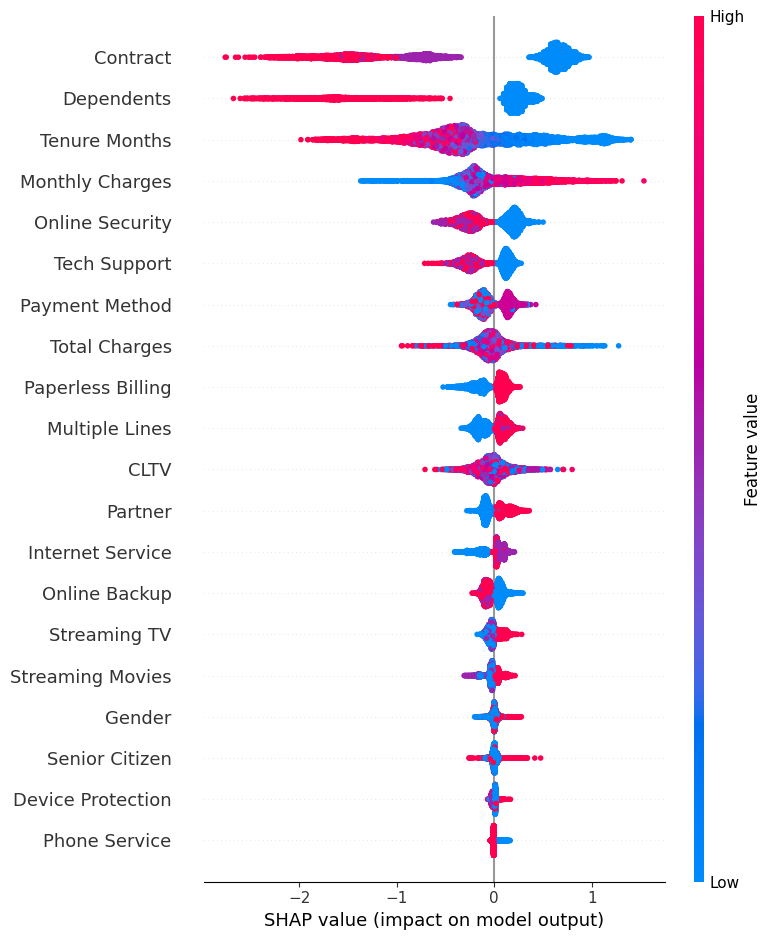

In [15]:
shap.summary_plot(
    shap_values,
    X
)

In [16]:
print(model)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)


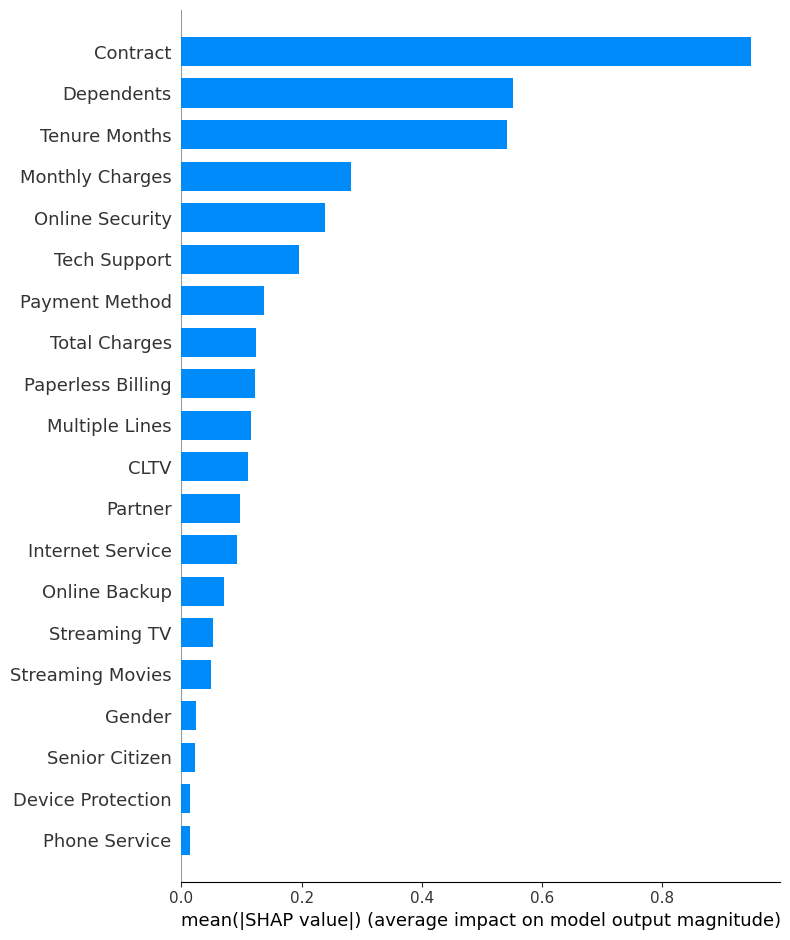

In [17]:
shap.summary_plot(
    shap_values,
    X,
    plot_type="bar"
)

# Key Drivers of Customer Churn

## High Churn Risk

- Month-to-month contracts
- Low tenure customers
- High monthly charges
- Lack of tech support
- Lack of online security

## Low Churn Risk

- Long-term contracts
- High tenure customers
- Customers using additional services
- Customers with tech support subscriptions

In [18]:
import joblib

joblib.dump(
    model,
    "../models/churn_model.joblib"
)

['../models/churn_model.joblib']

In [19]:
import os

os.listdir("../models")

['churn_model.joblib', 'encoders.joblib', 'scaler.joblib']

In [20]:
df = pd.read_csv(
    "../data/processed/processed_telco.csv"
)

feature_columns = df.drop(
    columns=["Churn Value"]
).columns.tolist()

print(feature_columns)

['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'CLTV']
